In [17]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
%autoreload 2

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator

from qlbm.circuits import encode, encode_links, propagation, macros, recover_quantity_quantum_macros
from qlbm.physics import get_collision_diagonal, bc_config_to_matrix, combine_collision_bc_matrices, collision_nonuniform
from qlbm.initial_conditions import *
from qlbm.analysis import count_gates, transpile_stage

## Helpers

In [19]:
simulator = StatevectorSimulator()
BASIS_GATES = ['rz', 'sx', 'x', 'cx']


def analyse_config(
    label: str,
    sites_per_dim: list[int],
    links: list[list[int]],
    weights: list[float],
    speed_of_sound: float,
    velocity_field: np.ndarray,
    boundary_conditions: np.ndarray | None,
) -> list[dict]:
    """Build and transpile every stage for one configuration. Returns per-stage dicts."""
    site_qubits_per_dim = [int(np.ceil(np.log2(s))) for s in sites_per_dim]
    site_qubits = int(np.sum(site_qubits_per_dim))
    num_links = len(links)
    link_qubits = int(np.ceil(np.log2(num_links)))
    num_qubits = site_qubits + link_qubits + 1

    # Build collision matrix
    collision_diag = get_collision_diagonal(link_qubits, links, weights, velocity_field, speed_of_sound)
    bc_matrix = None
    if boundary_conditions is not None:
        grid_size = int(np.prod(sites_per_dim))
        padded_nv = 2 ** link_qubits
        nv_actual = boundary_conditions.shape[-1]
        ndim_spatial = boundary_conditions.ndim - 2
        if ndim_spatial > 1:
            perm = list(reversed(range(ndim_spatial))) + [ndim_spatial, ndim_spatial + 1]
            bc_flat = np.ascontiguousarray(np.transpose(boundary_conditions, perm)).reshape(grid_size, nv_actual, nv_actual)
        else:
            bc_flat = boundary_conditions
        bc_matrix = bc_config_to_matrix(bc_flat, grid_size, padded_nv)
    combined = combine_collision_bc_matrices(collision_diag, bc_matrix)

    print(f"\n{'='*60}")
    print(f"Config: {label}")
    print(f"  sites={sites_per_dim}  links={num_links}  site_qubits={site_qubits}  link_qubits={link_qubits}  total_qubits={num_qubits}")
    print(f"  BCs: {'yes' if boundary_conditions is not None else 'no'}")
    print(f"{'='*60}")

    results = []

    # --- Initialization (encode) ---
    initial_density = np.ones(sites_per_dim)  # dummy; just need the shape
    state = encode(initial_density, link_qubits)
    qc_init = QuantumCircuit(num_qubits)
    qc_init.initialize(state)
    transpiled_init = transpile(qc_init.decompose(), basis_gates=BASIS_GATES)
    gates_init = count_gates(transpiled_init)
    results.append({
        "config": label,
        "stage": "initialize",
        "total_gates": sum(gates_init.values()),
        "depth": transpiled_init.depth(),
        "gate_breakdown": gates_init,
    })

    # --- Encode links ---
    el_gate = encode_links(link_qubits, num_links).to_gate(label="encode_links")
    r = transpile_stage("encode_links", el_gate, num_qubits, list(range(site_qubits, num_qubits - 1)), basis_gates=BASIS_GATES)
    r["config"] = label
    results.append(r)

    # --- Collision ---
    col_gate = collision_nonuniform(site_qubits, link_qubits, combined).to_gate(label="collision")
    r = transpile_stage("collision", col_gate, num_qubits, list(range(num_qubits)), basis_gates=BASIS_GATES)
    r["config"] = label
    results.append(r)

    # --- Propagation ---
    prop_gate = propagation(site_qubits_per_dim, link_qubits, links).to_gate(label="propagation")
    r = transpile_stage("propagation", prop_gate, num_qubits, list(range(0, num_qubits - 1)), basis_gates=BASIS_GATES)
    r["config"] = label
    results.append(r)

    # --- Macros ---
    mac_gate = macros(link_qubits).to_gate(label="macros")
    r = transpile_stage("macros", mac_gate, num_qubits, list(range(site_qubits, num_qubits)), basis_gates=BASIS_GATES)
    r["config"] = label
    results.append(r)

    for r in results:
        print(f"  {r['stage']:15s}  gates={r['total_gates']:>8,}  depth={r['depth']:>8,}")

    return results

## 1. D1Q3 — varying grid sizes

In [20]:
all_results = []

# D1Q3 lattice
links_d1q3 = [[-1], [0], [1]]
weights_d1q3 = [1/6, 2/3, 1/6]
cs = 1 / np.sqrt(3)

for N in [4, 8, 16, 32]:
    vf = get_uniform_velocity_field(N, velocity=0.3)
    all_results.extend(analyse_config(
        f"D1Q3 N={N}", [N], links_d1q3, weights_d1q3, cs, vf, None,
    ))


Config: D1Q3 N=4
  sites=[4]  links=3  site_qubits=2  link_qubits=2  total_qubits=5
  BCs: no
  initialize       gates=      86  depth=      81
  encode_links     gates=       6  depth=       3
  collision        gates=     395  depth=     273
  propagation      gates=     101  depth=      69
  macros           gates=       6  depth=       3

Config: D1Q3 N=8
  sites=[8]  links=3  site_qubits=3  link_qubits=2  total_qubits=6
  BCs: no
  initialize       gates=     129  depth=     118
  encode_links     gates=       6  depth=       3
  collision        gates=     788  depth=     543
  propagation      gates=     663  depth=     491
  macros           gates=       6  depth=       3

Config: D1Q3 N=16
  sites=[16]  links=3  site_qubits=4  link_qubits=2  total_qubits=7
  BCs: no
  initialize       gates=     172  depth=     155
  encode_links     gates=       6  depth=       3
  collision        gates=   1,565  depth=   1,069
  propagation      gates=   1,947  depth=   1,453
  macros     

## 2. Effect of velocity field (uniform vs non-uniform)

In [21]:
N = 16

# Uniform velocity
vf_uniform = get_uniform_velocity_field(N, velocity=0.3)
all_results.extend(analyse_config(
    "D1Q3 N=16 uniform v", [N], links_d1q3, weights_d1q3, cs, vf_uniform, None,
))

# Spatially varying velocity (linear gradient)
vf_gradient = np.linspace(0.05, 0.35, N).reshape(1, N)
all_results.extend(analyse_config(
    "D1Q3 N=16 gradient v", [N], links_d1q3, weights_d1q3, cs, vf_gradient, None,
))

# Zero velocity
vf_zero = np.zeros((1, N))
all_results.extend(analyse_config(
    "D1Q3 N=16 zero v", [N], links_d1q3, weights_d1q3, cs, vf_zero, None,
))


Config: D1Q3 N=16 uniform v
  sites=[16]  links=3  site_qubits=4  link_qubits=2  total_qubits=7
  BCs: no
  initialize       gates=     172  depth=     155
  encode_links     gates=       6  depth=       3
  collision        gates=   1,565  depth=   1,069
  propagation      gates=   1,947  depth=   1,453
  macros           gates=       6  depth=       3

Config: D1Q3 N=16 gradient v
  sites=[16]  links=3  site_qubits=4  link_qubits=2  total_qubits=7
  BCs: no
  initialize       gates=     172  depth=     155
  encode_links     gates=       6  depth=       3
  collision        gates=   2,275  depth=   1,721
  propagation      gates=   1,947  depth=   1,453
  macros           gates=       6  depth=       3

Config: D1Q3 N=16 zero v
  sites=[16]  links=3  site_qubits=4  link_qubits=2  total_qubits=7
  BCs: no
  initialize       gates=     172  depth=     155
  encode_links     gates=       6  depth=       3
  collision        gates=   1,567  depth=   1,070
  propagation      gates=   1,9

## 3. Effect of boundary conditions (1D)

In [22]:
for N in [4, 8, 16, 32]:
    vf = get_uniform_velocity_field(N, velocity=0.3)
    bc = create_bounceback_bc_1d(N, links_d1q3)
    all_results.extend(analyse_config(
        f"D1Q3 N={N} +BC", [N], links_d1q3, weights_d1q3, cs, vf, bc,
    ))

Velocity indices: left=0, stationary=1, right=2

Config: D1Q3 N=4 +BC
  sites=[4]  links=3  site_qubits=2  link_qubits=2  total_qubits=5
  BCs: yes
Using SVD decomposition for non-diagonal collision matrix
Decomposition complete
Added manually-constructed controlled unitaries to circuit
  initialize       gates=      86  depth=      81
  encode_links     gates=       6  depth=       3
  collision        gates=   2,282  depth=   1,432
  propagation      gates=     101  depth=      69
  macros           gates=       6  depth=       3
Velocity indices: left=0, stationary=1, right=2

Config: D1Q3 N=8 +BC
  sites=[8]  links=3  site_qubits=3  link_qubits=2  total_qubits=6
  BCs: yes
Using SVD decomposition for non-diagonal collision matrix
Decomposition complete
Added manually-constructed controlled unitaries to circuit
  initialize       gates=     129  depth=     118
  encode_links     gates=       6  depth=       3
  collision        gates=   9,451  depth=   6,008
  propagation      gates

## 4. 2D and 3D configurations

In [23]:
# D2Q9 lattice
links_d2q9 = [[0,0], [-1,0], [1,0], [0,-1], [0,1], [-1,-1], [-1,1], [1,-1], [1,1]]
weights_d2q9 = [4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36]

# 2D shear flow — 8x8
vf_2d = get_shear_velocity_field((8, 8), u_magnitude=0.2, v_magnitude=0.1)
all_results.extend(analyse_config(
    "D2Q9 8x8 shear", [8, 8], links_d2q9, weights_d2q9, cs, vf_2d, None,
))

# 2D vortex flow — 8x8
vf_vortex = get_vortex_velocity_field((8, 8), magnitude=0.5)
all_results.extend(analyse_config(
    "D2Q9 8x8 vortex", [8, 8], links_d2q9, weights_d2q9, cs, vf_vortex, None,
))

# Non-standard links — 8x8
links_nonstandard = [[0,0], [2,1], [-2,-1]]
weights_nonstandard = [2/3, 1/6, 1/6]
vf_zero_2d = np.zeros((2, 8, 8))
all_results.extend(analyse_config(
    "D2 nonstandard 8x8", [8, 8], links_nonstandard, weights_nonstandard, cs, vf_zero_2d, None,
))

# D2Q5 4x4 — without and with BCs (for BC overhead comparison)
links_d2q5 = [[0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]]
weights_d2q5 = [1/3, 1/6, 1/6, 1/6, 1/6]
vf_bc = get_shear_velocity_field((4, 4), u_magnitude=0.2, v_magnitude=0.1)

all_results.extend(analyse_config(
    "D2Q5 4x4", [4, 4], links_d2q5, weights_d2q5, cs, vf_bc, None,
))

bc_2d = create_split_walls_bc_2d((4, 4), links_d2q5)
all_results.extend(analyse_config(
    "D2Q5 4x4 +BC", [4, 4], links_d2q5, weights_d2q5, cs, vf_bc, bc_2d,
))

# D3Q27 — 4x4x4
links_d3q27 = [
    [0,0,0],
    [-1,0,0], [1,0,0], [0,-1,0], [0,1,0], [0,0,-1], [0,0,1],
    [-1,-1,0], [-1,1,0], [1,-1,0], [1,1,0],
    [-1,0,-1], [-1,0,1], [1,0,-1], [1,0,1],
    [0,-1,-1], [0,-1,1], [0,1,-1], [0,1,1],
    [-1,-1,-1], [-1,-1,1], [-1,1,-1], [-1,1,1],
    [1,-1,-1], [1,-1,1], [1,1,-1], [1,1,1],
]
weights_d3q27 = [
    8/27 if all(v == 0 for v in link) else
    2/27 if sum(abs(v) for v in link) == 1 else
    1/54 if sum(abs(v) for v in link) == 2 else
    1/216
    for link in links_d3q27
]
vf_3d = get_3d_velocity_field((4, 4, 4), A=0.2, B=0.2, C=0.2, a=1.0, b=1.0, c=1.0)
all_results.extend(analyse_config(
    "D3Q27 4x4x4", [4, 4, 4], links_d3q27, weights_d3q27, cs, vf_3d, None,
))


Config: D2Q9 8x8 shear
  sites=[8, 8]  links=9  site_qubits=6  link_qubits=4  total_qubits=11
  BCs: no
  initialize       gates=   1,122  depth=   1,093
  encode_links     gates=      12  depth=       3
  collision        gates=  24,993  depth=  16,787
  propagation      gates=  14,890  depth=  11,660
  macros           gates=      12  depth=       3

Config: D2Q9 8x8 vortex
  sites=[8, 8]  links=9  site_qubits=6  link_qubits=4  total_qubits=11
  BCs: no
  initialize       gates=   1,122  depth=   1,093
  encode_links     gates=      12  depth=       3
  collision        gates=  38,795  depth=  30,509
  propagation      gates=  14,890  depth=  11,660
  macros           gates=      12  depth=       3

Config: D2 nonstandard 8x8
  sites=[8, 8]  links=3  site_qubits=6  link_qubits=2  total_qubits=9
  BCs: no
  initialize       gates=     258  depth=     229
  encode_links     gates=       6  depth=       3
  collision        gates=   6,194  depth=   4,170
  propagation      gates=   1,9

## Results table

In [24]:
df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "gate_breakdown"}
    for r in all_results
])

stages = ["initialize", "encode_links", "collision", "propagation", "macros"]

pivot_gates = df.pivot_table(index="config", columns="stage", values="total_gates", sort=False)[stages]
print("Gate counts per stage:")
display(pivot_gates)

pivot_depth = df.pivot_table(index="config", columns="stage", values="depth", sort=False)[stages]
print("\nCircuit depth per stage:")
display(pivot_depth)

Gate counts per stage:


stage,initialize,encode_links,collision,propagation,macros
config,,,,,
D1Q3 N=4,86.0,6.0,395.0,101.0,6.0
D1Q3 N=8,129.0,6.0,788.0,663.0,6.0
D1Q3 N=16,172.0,6.0,1565.0,1947.0,6.0
D1Q3 N=32,215.0,6.0,3110.0,5839.0,6.0
D1Q3 N=16 uniform v,172.0,6.0,1565.0,1947.0,6.0
D1Q3 N=16 gradient v,172.0,6.0,2275.0,1947.0,6.0
D1Q3 N=16 zero v,172.0,6.0,1567.0,1947.0,6.0
D1Q3 N=4 +BC,86.0,6.0,2282.0,101.0,6.0
D1Q3 N=8 +BC,129.0,6.0,9451.0,663.0,6.0



Circuit depth per stage:


stage,initialize,encode_links,collision,propagation,macros
config,,,,,
D1Q3 N=4,81.0,3.0,273.0,69.0,3.0
D1Q3 N=8,118.0,3.0,543.0,491.0,3.0
D1Q3 N=16,155.0,3.0,1069.0,1453.0,3.0
D1Q3 N=32,192.0,3.0,2107.0,4359.0,3.0
D1Q3 N=16 uniform v,155.0,3.0,1069.0,1453.0,3.0
D1Q3 N=16 gradient v,155.0,3.0,1721.0,1453.0,3.0
D1Q3 N=16 zero v,155.0,3.0,1070.0,1453.0,3.0
D1Q3 N=4 +BC,81.0,3.0,1432.0,69.0,3.0
D1Q3 N=8 +BC,118.0,3.0,6008.0,491.0,3.0


In [25]:
# Export main transpilation data to CSV
stages = ["initialize", "encode_links", "collision", "propagation", "macros"]

export_rows = []
configs_seen = []
for r in all_results:
    cfg = r["config"]
    if cfg not in configs_seen:
        configs_seen.append(cfg)

# Build one row per config with gates/depth per stage
for cfg in configs_seen:
    stage_data = {r["stage"]: r for r in all_results if r["config"] == cfg}
    row = {"config": cfg}
    total_g, total_d = 0, 0
    for s in stages:
        d = stage_data.get(s, {})
        g = d.get("total_gates", 0)
        dep = d.get("depth", 0)
        row[f"{s}_gates"] = g
        row[f"{s}_depth"] = dep
        total_g += g
        total_d += dep
    row["total_gates"] = total_g
    row["total_depth"] = total_d
    export_rows.append(row)

df_export = pd.DataFrame(export_rows)
df_export.to_csv("experiments/transpilation_stages.csv", index=False)
print(f"Saved {len(df_export)} rows to experiments/transpilation_stages.csv")
display(df_export)

Saved 17 rows to experiments/transpilation_stages.csv


,config,initialize_gates,initialize_depth,encode_links_gates,encode_links_depth,collision_gates,collision_depth,propagation_gates,propagation_depth,macros_gates,macros_depth,total_gates,total_depth
0,D1Q3 N=4,86,81,6,3,395,273,101,69,6,3,594,429
1,D1Q3 N=8,129,118,6,3,788,543,663,491,6,3,1592,1158
2,D1Q3 N=16,172,155,6,3,1565,1069,1947,1453,6,3,3696,2683
3,D1Q3 N=32,215,192,6,3,3110,2107,5839,4359,6,3,9176,6664
4,D1Q3 N=16 uniform v,172,155,6,3,1565,1069,1947,1453,6,3,3696,2683
5,D1Q3 N=16 gradient v,172,155,6,3,2275,1721,1947,1453,6,3,4406,3335
6,D1Q3 N=16 zero v,172,155,6,3,1567,1070,1947,1453,6,3,3698,2684
7,D1Q3 N=4 +BC,86,81,6,3,2282,1432,101,69,6,3,2481,1588
8,D1Q3 N=8 +BC,129,118,6,3,9451,6008,663,491,6,3,10255,6623
9,D1Q3 N=16 +BC,172,155,6,3,38380,24568,1947,1453,6,3,40511,26182


## Gate count visualisation

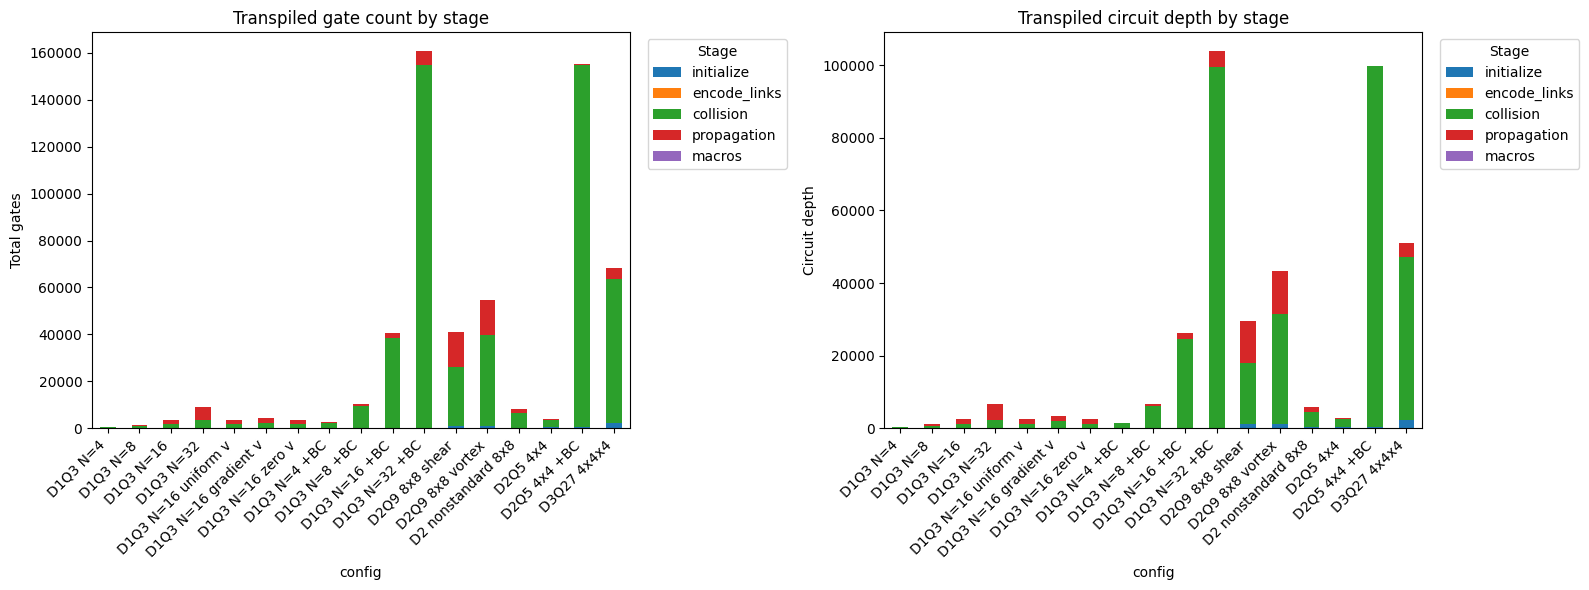

In [26]:
stages = ["initialize", "encode_links", "collision", "propagation", "macros"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_gates.fillna(0)[stages].plot.bar(stacked=True, ax=axes[0])
axes[0].set_ylabel("Total gates")
axes[0].set_title("Transpiled gate count by stage")
axes[0].legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")

pivot_depth.fillna(0)[stages].plot.bar(stacked=True, ax=axes[1])
axes[1].set_ylabel("Circuit depth")
axes[1].set_title("Transpiled circuit depth by stage")
axes[1].legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

plt.tight_layout()
plt.show()

## Detailed gate breakdown for selected configs

In [27]:
highlight_configs = [
    "D1Q3 N=16", "D1Q3 N=16 +BC",
    "D2Q9 8x8 shear", "D2Q5 4x4 +BC",
    "D3Q27 4x4x4",
]

for r in all_results:
    if r["config"] in highlight_configs and r["stage"] in ("initialize", "collision"):
        print(f"\n{r['config']} / {r['stage']}:")
        breakdown = r["gate_breakdown"]
        for gate_name, cnt in sorted(breakdown.items(), key=lambda x: -x[1]):
            print(f"  {gate_name:20s} {cnt:>8,}")


D1Q3 N=16 / initialize:
  rz                         88
  sx                         56
  cx                         28

D1Q3 N=16 / collision:
  rz                        783
  cx                        748
  sx                         24
  x                          10

D1Q3 N=16 +BC / initialize:
  rz                         88
  sx                         56
  cx                         28

D1Q3 N=16 +BC / collision:
  rz                     19,193
  sx                     10,910
  cx                      8,277

D2Q9 8x8 shear / initialize:
  rz                        564
  sx                        372
  cx                        186

D2Q9 8x8 shear / collision:
  rz                     12,476
  cx                     12,376
  sx                        136
  x                           5

D2Q5 4x4 +BC / initialize:
  rz                        184
  sx                        120
  cx                         60

D2Q5 4x4 +BC / collision:
  rz                     77,309
  sx        

## 5. Per-iteration initialization gate count (D2Q9 8x8 shear)

Since `initialize` is re-synthesized every iteration with the updated density, the initialization gate count may vary across iterations.

In [28]:
def per_iteration_stats(
    label: str,
    initial_density: np.ndarray,
    velocity_field: np.ndarray,
    links: list[list[int]],
    weights: list[float],
    speed_of_sound: float,
    boundary_conditions: np.ndarray | None,
    num_iterations: int = 10,
) -> pd.DataFrame:
    """Run iterations and record gate count / depth at each step."""
    sites_per_dim = list(initial_density.shape)
    site_qubits_per_dim = [int(np.ceil(np.log2(s))) for s in sites_per_dim]
    site_qubits = int(np.sum(site_qubits_per_dim))
    num_links = len(links)
    link_qubits = int(np.ceil(np.log2(num_links)))
    num_qubits = site_qubits + link_qubits + 1
    original_sum = np.float64(np.sum(initial_density))

    collision_diag = get_collision_diagonal(link_qubits, links, weights, velocity_field, speed_of_sound)
    bc_matrix = None
    if boundary_conditions is not None:
        grid_size = int(np.prod(sites_per_dim))
        padded_nv = 2 ** link_qubits
        nv_actual = boundary_conditions.shape[-1]
        ndim_spatial = boundary_conditions.ndim - 2
        if ndim_spatial > 1:
            perm = list(reversed(range(ndim_spatial))) + [ndim_spatial, ndim_spatial + 1]
            bc_flat = np.ascontiguousarray(np.transpose(boundary_conditions, perm)).reshape(grid_size, nv_actual, nv_actual)
        else:
            bc_flat = boundary_conditions
        bc_matrix = bc_config_to_matrix(bc_flat, grid_size, padded_nv)
    combined = combine_collision_bc_matrices(collision_diag, bc_matrix)

    # Pre-transpile reusable stages (basis_gates for counting, simulator for running)
    el_gate = encode_links(link_qubits, num_links).to_gate(label="encode_links")
    qc_tmp = QuantumCircuit(num_qubits)
    qc_tmp.append(el_gate, list(range(site_qubits, num_qubits - 1)))
    cached_el = transpile(qc_tmp, simulator)
    counted_el = transpile(qc_tmp, basis_gates=BASIS_GATES)

    col_gate = collision_nonuniform(site_qubits, link_qubits, combined).to_gate(label="collision")
    qc_tmp = QuantumCircuit(num_qubits)
    qc_tmp.append(col_gate, list(range(num_qubits)))
    cached_col = transpile(qc_tmp, simulator)
    counted_col = transpile(qc_tmp, basis_gates=BASIS_GATES)

    prop_gate = propagation(site_qubits_per_dim, link_qubits, links).to_gate(label="propagation")
    qc_tmp = QuantumCircuit(num_qubits)
    qc_tmp.append(prop_gate, list(range(0, num_qubits - 1)))
    cached_prop = transpile(qc_tmp, simulator)
    counted_prop = transpile(qc_tmp, basis_gates=BASIS_GATES)

    mac_gate = macros(link_qubits).to_gate(label="macros")
    qc_tmp = QuantumCircuit(num_qubits)
    qc_tmp.append(mac_gate, list(range(site_qubits, num_qubits)))
    cached_mac = transpile(qc_tmp, simulator)
    counted_mac = transpile(qc_tmp, basis_gates=BASIS_GATES)

    # Fixed stage counts (don't change per iteration)
    fixed_gates = (sum(count_gates(counted_el).values())
                   + sum(count_gates(counted_col).values())
                   + sum(count_gates(counted_prop).values())
                   + sum(count_gates(counted_mac).values()))

    density = initial_density.copy()
    rows = []

    for i in range(num_iterations):
        state = encode(density, link_qubits)

        # Transpile initialize against basis gates for counting
        qc_init = QuantumCircuit(num_qubits)
        qc_init.initialize(state)
        try:
            transpiled_init = transpile(qc_init.decompose(), basis_gates=BASIS_GATES)
            init_total = sum(count_gates(transpiled_init).values())
            init_depth = transpiled_init.depth()
        except Exception as e:
            print(f"  iter {i+1:3d}  transpilation failed: {e}")
            break

        # Run simulation using the simulator-compatible circuits
        qc = QuantumCircuit(num_qubits)
        qc.initialize(state)
        qc.compose(cached_el, inplace=True)
        qc.compose(cached_col, inplace=True)
        qc.compose(cached_prop, inplace=True)
        qc.compose(cached_mac, inplace=True)

        job = simulator.run(qc)
        result = job.result()
        state = result.get_statevector()
        del job, result, qc
        gc.collect()

        density = recover_quantity_quantum_macros(state, sites_per_dim, num_links, original_sum)

        rows.append({
            "iteration": i + 1,
            "init_gates": init_total,
            "init_depth": init_depth,
            "fixed_stage_gates": fixed_gates,
            "total_gates": init_total + fixed_gates,
        })
        print(f"  iter {i+1:3d}  init_gates={init_total:>6,}  total_gates={init_total + fixed_gates:>6,}")

    return pd.DataFrame(rows)

In [29]:
density_2d = get_ring_initial_distribution((8, 8), cylinder_radius_outer=3, cylinder_radius_inner=1)
vf_2d_shear = get_shear_velocity_field((8, 8), u_magnitude=0.2, v_magnitude=0.1)

df_init = per_iteration_stats(
    "D2Q9 8x8 shear", density_2d, vf_2d_shear,
    links_d2q9, weights_d2q9, cs, None, num_iterations=10,
)

  iter   1  init_gates= 8,449  total_gates=48,356
  iter   2  init_gates=10,367  total_gates=50,274
  iter   3  init_gates=10,404  total_gates=50,311
  iter   4  init_gates=10,306  total_gates=50,213
  iter   5  init_gates=10,617  total_gates=50,524
  iter   6  init_gates=10,514  total_gates=50,421
  iter   7  init_gates=10,250  total_gates=50,157
  iter   8  init_gates=10,370  total_gates=50,277
  iter   9  init_gates=10,270  total_gates=50,177
  iter  10  transpilation failed: 'HighLevelSynthesis is unable to synthesize "state_preparation"'


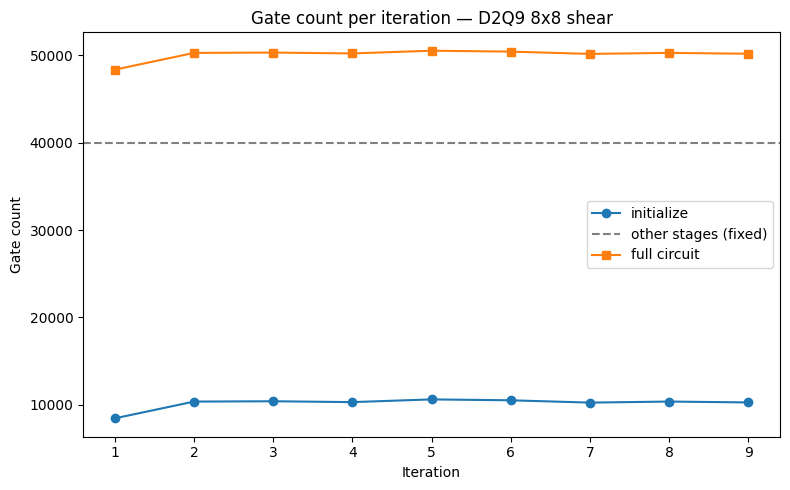

,iteration,init_gates,init_depth,fixed_stage_gates,total_gates
0,1,8449,8435,39907,48356
1,2,10367,10353,39907,50274
2,3,10404,10390,39907,50311
3,4,10306,10292,39907,50213
4,5,10617,10603,39907,50524
5,6,10514,10500,39907,50421
6,7,10250,10236,39907,50157
7,8,10370,10356,39907,50277
8,9,10270,10256,39907,50177


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_init["iteration"], df_init["init_gates"], "o-", label="initialize")
ax.axhline(df_init["fixed_stage_gates"].iloc[0], ls="--", color="grey", label="other stages (fixed)")
ax.plot(df_init["iteration"], df_init["total_gates"], "s-", label="full circuit")
ax.set_ylabel("Gate count")
ax.set_xlabel("Iteration")
ax.set_title("Gate count per iteration \u2014 D2Q9 8x8 shear")
ax.legend()

plt.tight_layout()
plt.show()

display(df_init)

In [31]:
# Export per-iteration initialization data to CSV
df_init.to_csv("experiments/transpilation_per_iteration_init.csv", index=False)
print(f"Saved {len(df_init)} rows to experiments/transpilation_per_iteration_init.csv")
display(df_init)

Saved 9 rows to experiments/transpilation_per_iteration_init.csv


,iteration,init_gates,init_depth,fixed_stage_gates,total_gates
0,1,8449,8435,39907,48356
1,2,10367,10353,39907,50274
2,3,10404,10390,39907,50311
3,4,10306,10292,39907,50213
4,5,10617,10603,39907,50524
5,6,10514,10500,39907,50421
6,7,10250,10236,39907,50157
7,8,10370,10356,39907,50277
8,9,10270,10256,39907,50177
